# SKAB Anomaly Detection — Supervised vs Unsupervised
**Dataset:** valve1 files (16 CSVs)  
**Supervised:** XGBoost, Random Forest  
**Unsupervised:** Isolation Forest, LSTM Autoencoder  
**Evaluation:** F1, Precision, Recall, ROC-AUC per file + overall

## Cell 1 — Install Dependencies

In [ ]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn torch

## Cell 2 — Upload Your archive.zip

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload archive.zip here
print('Uploaded:', list(uploaded.keys()))

Saving archive.zip to archive.zip
Uploaded: ['archive.zip']


## Cell 3 — Load All valve1 Files + Anomaly-Free Baseline

In [ ]:
import zipfile
import pandas as pd
import numpy as np

FEATURE_COLS = [
    'Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
    'Pressure', 'Temperature', 'Thermocouple',
    'Voltage', 'Volume Flow RateRMS'
]

def load_csv_from_zip(z, path):
    with z.open(path) as f:
        df = pd.read_csv(f, sep=';', parse_dates=['datetime'])
    df = df.sort_values('datetime').reset_index(drop=True)
    return df

valve1_files = [f'SKAB/valve1/{i}.csv' for i in range(16)]

with zipfile.ZipFile('archive.zip', 'r') as z:
    # Anomaly-free baseline for unsupervised training
    baseline_df = load_csv_from_zip(z, 'SKAB/anomaly-free/anomaly-free.csv')

    # All valve1 files
    valve1_dfs = []
    for f in valve1_files:
        df = load_csv_from_zip(z, f)
        df['source_file'] = f.split('/')[-1]
        valve1_dfs.append(df)

all_valve1 = pd.concat(valve1_dfs, ignore_index=True)

print(f'Baseline (anomaly-free) shape: {baseline_df.shape}')
print(f'Total valve1 rows: {len(all_valve1)}')
print(f'Overall anomaly rate: {all_valve1["anomaly"].mean():.1%}')
print(f'Files loaded: {all_valve1["source_file"].nunique()}')

Baseline (anomaly-free) shape: (9401, 9)
Total valve1 rows: 18162
Overall anomaly rate: 34.7%
Files loaded: 16


## Cell 4 — Feature Engineering

In [ ]:
from sklearn.preprocessing import StandardScaler

def add_rolling_features(df, window=5):
    """Add rolling mean and std for each sensor feature."""
    df = df.copy()
    for col in FEATURE_COLS:
        df[f'{col}_roll_mean'] = df[col].rolling(window, min_periods=1).mean()
        df[f'{col}_roll_std']  = df[col].rolling(window, min_periods=1).std().fillna(0)
    return df

# Add rolling features
baseline_feat = add_rolling_features(baseline_df)
valve1_feat   = add_rolling_features(all_valve1)

EXTENDED_COLS = FEATURE_COLS + \
    [f'{c}_roll_mean' for c in FEATURE_COLS] + \
    [f'{c}_roll_std'  for c in FEATURE_COLS]

# Fit scaler on baseline only (unsupervised philosophy)
scaler = StandardScaler()
scaler.fit(baseline_feat[EXTENDED_COLS])

X_baseline = scaler.transform(baseline_feat[EXTENDED_COLS])
X_valve1   = scaler.transform(valve1_feat[EXTENDED_COLS])
y_valve1   = valve1_feat['anomaly'].values

print(f'Feature matrix shape (valve1): {X_valve1.shape}')
print(f'Labels shape: {y_valve1.shape}')

Feature matrix shape (valve1): (18162, 24)
Labels shape: (18162,)


## Cell 5 — UNSUPERVISED: Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score, roc_auc_score

print('Training Isolation Forest on anomaly-free baseline...')
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # expect ~5% anomalies in baseline
    random_state=42,
    n_jobs=-1
)
iso.fit(X_baseline)

# Predict on all valve1 data (-1 = anomaly, 1 = normal)
iso_raw   = iso.predict(X_valve1)
iso_preds = (iso_raw == -1).astype(int)  # convert to 0/1
iso_scores = -iso.score_samples(X_valve1)  # higher = more anomalous

print('\n=== Isolation Forest Results ===')
print(classification_report(y_valve1, iso_preds, target_names=['Normal','Anomaly']))
print(f'ROC-AUC: {roc_auc_score(y_valve1, iso_scores):.4f}')

Training Isolation Forest on anomaly-free baseline...

=== Isolation Forest Results ===
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     11853
     Anomaly       0.35      1.00      0.52      6309

    accuracy                           0.35     18162
   macro avg       0.17      0.50      0.26     18162
weighted avg       0.12      0.35      0.18     18162

ROC-AUC: 0.4868


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Cell 6 — UNSUPERVISED: LSTM Autoencoder

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

WINDOW   = 30   # sequence length
LATENT   = 32
EPOCHS   = 20
BATCH    = 64
LR       = 1e-3
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

def make_sequences(data, window):
    seqs = [data[i:i+window] for i in range(len(data) - window)]
    return np.stack(seqs).astype(np.float32)

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, latent_dim):
        super().__init__()
        self.encoder = nn.LSTM(n_features, latent_dim, batch_first=True)
        self.decoder = nn.LSTM(latent_dim, n_features, batch_first=True)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        h = h.squeeze(0).unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(h)
        return out

n_features = X_baseline.shape[1]
model = LSTMAutoencoder(n_features, LATENT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# Train on baseline sequences only
train_seqs = torch.tensor(make_sequences(X_baseline, WINDOW))
loader = DataLoader(TensorDataset(train_seqs), batch_size=BATCH, shuffle=True)

print(f'Training LSTM Autoencoder for {EPOCHS} epochs...')
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for (batch,) in loader:
        batch = batch.to(device)
        recon = model(batch)
        loss  = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(loader):.6f}')

# Compute reconstruction error on valve1
model.eval()
test_seqs = make_sequences(X_valve1, WINDOW)
recon_errors = []
with torch.no_grad():
    for i in range(0, len(test_seqs), BATCH):
        batch = torch.tensor(test_seqs[i:i+BATCH]).to(device)
        recon = model(batch)
        err   = ((recon - batch) ** 2).mean(dim=(1, 2)).cpu().numpy()
        recon_errors.extend(err)

# Align errors with original labels (window offset)
recon_errors = np.array(recon_errors)
y_lstm = y_valve1[WINDOW:]

# Threshold = 95th percentile of baseline reconstruction error
baseline_seqs = make_sequences(X_baseline, WINDOW)
baseline_errors = []
with torch.no_grad():
    for i in range(0, len(baseline_seqs), BATCH):
        batch = torch.tensor(baseline_seqs[i:i+BATCH]).to(device)
        recon = model(batch)
        err   = ((recon - batch) ** 2).mean(dim=(1, 2)).cpu().numpy()
        baseline_errors.extend(err)

threshold = np.percentile(baseline_errors, 95)
lstm_preds = (recon_errors > threshold).astype(int)

print(f'\nThreshold (95th pct of baseline error): {threshold:.6f}')
print('\n=== LSTM Autoencoder Results ===')
print(classification_report(y_lstm, lstm_preds, target_names=['Normal','Anomaly']))
print(f'ROC-AUC: {roc_auc_score(y_lstm, recon_errors):.4f}')

Using device: cpu
Training LSTM Autoencoder for 20 epochs...
  Epoch 5/20  Loss: 0.595753
  Epoch 10/20  Loss: 0.576674
  Epoch 15/20  Loss: 0.567956
  Epoch 20/20  Loss: 0.563394

Threshold (95th pct of baseline error): 0.905373

=== LSTM Autoencoder Results ===
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     11823
     Anomaly       0.35      1.00      0.52      6309

    accuracy                           0.35     18132
   macro avg       0.17      0.50      0.26     18132
weighted avg       0.12      0.35      0.18     18132

ROC-AUC: 0.7118


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Cell 7 — SUPERVISED: XGBoost + Random Forest (Cross-Validated)

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, f1_score, roc_auc_score

# Use file name as group so each fold tests on unseen files
groups = valve1_feat['source_file'].values
neg = (y_valve1 == 0).sum()
pos = (y_valve1 == 1).sum()
scale_pos = neg / pos

models = {
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        scale_pos_weight=scale_pos,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

gkf = GroupKFold(n_splits=5)
supervised_results = {}

for name, clf in models.items():
    print(f'\n=== {name} (Group 5-Fold CV) ===')
    all_preds  = np.zeros(len(y_valve1))
    all_probas = np.zeros(len(y_valve1))

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_valve1, y_valve1, groups)):
        clf.fit(X_valve1[train_idx], y_valve1[train_idx])
        all_preds[test_idx]  = clf.predict(X_valve1[test_idx])
        all_probas[test_idx] = clf.predict_proba(X_valve1[test_idx])[:, 1]
        f1 = f1_score(y_valve1[test_idx], all_preds[test_idx])
        print(f'  Fold {fold+1}  F1: {f1:.4f}')

    print(classification_report(y_valve1, all_preds, target_names=['Normal','Anomaly']))
    print(f'ROC-AUC: {roc_auc_score(y_valve1, all_probas):.4f}')
    supervised_results[name] = {
        'preds': all_preds, 'probas': all_probas
    }


=== XGBoost (Group 5-Fold CV) ===


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:38:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 1  F1: 0.8957


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:38:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 2  F1: 0.8875


...

  Fold 3  F1: 0.8325


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:38:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 4  F1: 0.9055


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:38:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 5  F1: 0.7377
              precision    recall  f1-score   support

      Normal       0.89      0.97      0.93     11853
     Anomaly       0.93      0.78      0.85      6309

    accuracy                           0.90     18162
   macro avg       0.91      0.88      0.89     18162
weighted avg       0.91      0.90      0.90     18162

ROC-AUC: 0.9032

=== Random Forest (Group 5-Fold CV) ===
  Fold 1  F1: 0.9078
  Fold 2  F1: 0.9037
  Fold 3  F1: 0.7010
  Fold 4  F1: 0.9153
  Fold 5  F1: 0.7625
              precision    recall  f1-score   support

      Normal       0.88      0.99      0.93     11853
     Anomaly       0.98      0.74      0.84      6309

    accuracy                           0.90     18162
   macro avg       0.93      0.86      0.89     18162
weighted avg       0.91      0.90      0.90     18162

ROC-AUC: 0.8913


## Cell 8 — Summary Comparison Table

In [ ]:
from sklearn.metrics import precision_score, recall_score

results = []

# Isolation Forest
results.append({
    'Model': 'Isolation Forest',
    'Type': 'Unsupervised',
    'F1':        round(f1_score(y_valve1, iso_preds), 4),
    'Precision': round(precision_score(y_valve1, iso_preds), 4),
    'Recall':    round(recall_score(y_valve1, iso_preds), 4),
    'ROC-AUC':   round(roc_auc_score(y_valve1, iso_scores), 4)
})

# LSTM Autoencoder
results.append({
    'Model': 'LSTM Autoencoder',
    'Type': 'Unsupervised',
    'F1':        round(f1_score(y_lstm, lstm_preds), 4),
    'Precision': round(precision_score(y_lstm, lstm_preds), 4),
    'Recall':    round(recall_score(y_lstm, lstm_preds), 4),
    'ROC-AUC':   round(roc_auc_score(y_lstm, recon_errors), 4)
})

# Supervised models
for name, res in supervised_results.items():
    results.append({
        'Model': name,
        'Type': 'Supervised',
        'F1':        round(f1_score(y_valve1, res['preds']), 4),
        'Precision': round(precision_score(y_valve1, res['preds']), 4),
        'Recall':    round(recall_score(y_valve1, res['preds']), 4),
        'ROC-AUC':   round(roc_auc_score(y_valve1, res['probas']), 4)
    })

summary_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print('\n========== FINAL COMPARISON ==========')
print(summary_df.to_string(index=False))


========== FINAL COMPARISON ==========
           Model         Type     F1  Precision  Recall  ROC-AUC
         XGBoost   Supervised 0.8498     0.9311  0.7816   0.9032
   Random Forest   Supervised 0.8412     0.9784  0.7378   0.8913
LSTM Autoencoder Unsupervised 0.5163     0.3479  1.0000   0.7118
Isolation Forest Unsupervised 0.5156     0.3474  1.0000   0.4868


## Cell 9 — Visualisation: Anomaly Score Plot for One File

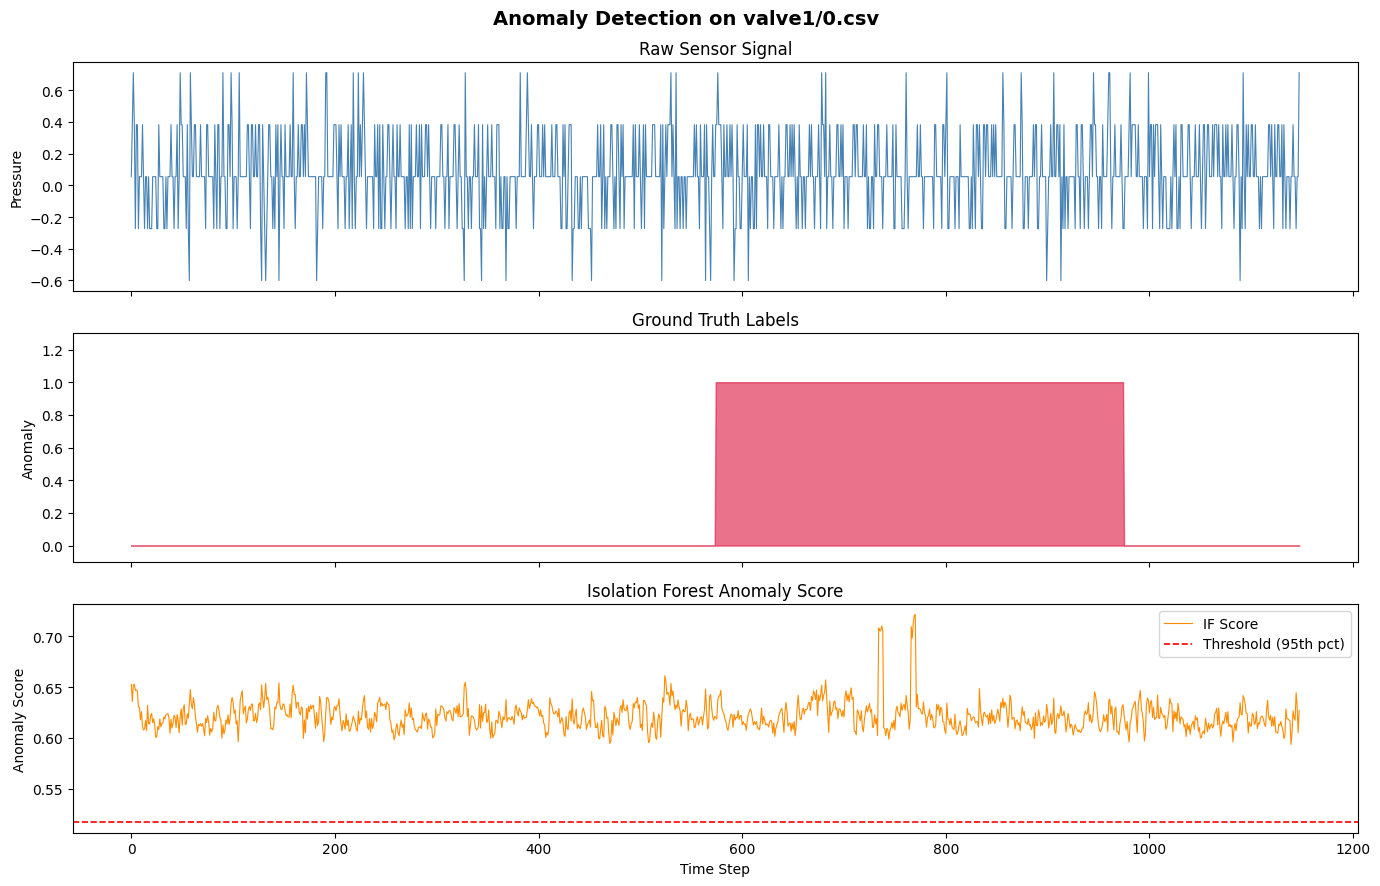

Plot saved as anomaly_plot.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Pick valve1/0.csv for visual inspection
mask = valve1_feat['source_file'] == '0.csv'
X_one = X_valve1[mask]
y_one = y_valve1[mask]

iso_scores_one = -iso.score_samples(X_one)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Anomaly Detection on valve1/0.csv', fontsize=14, fontweight='bold')

# Raw sensor signal
axes[0].plot(valve1_feat.loc[mask, 'Pressure'].values, color='steelblue', lw=0.8)
axes[0].set_ylabel('Pressure')
axes[0].set_title('Raw Sensor Signal')

# True anomaly labels
axes[1].fill_between(range(len(y_one)), y_one, alpha=0.6, color='crimson', label='True Anomaly')
axes[1].set_ylabel('Anomaly')
axes[1].set_title('Ground Truth Labels')
axes[1].set_ylim(-0.1, 1.3)

# Isolation Forest anomaly score
axes[2].plot(iso_scores_one, color='darkorange', lw=0.8, label='IF Score')
thresh_line = np.percentile(-iso.score_samples(X_baseline), 95)
axes[2].axhline(thresh_line, color='red', linestyle='--', lw=1.2, label='Threshold (95th pct)')
axes[2].set_ylabel('Anomaly Score')
axes[2].set_title('Isolation Forest Anomaly Score')
axes[2].legend()

plt.xlabel('Time Step')
plt.tight_layout()
plt.savefig('anomaly_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as anomaly_plot.png')

## Cell 10 — Per-File F1 Scores (XGBoost)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:40:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  File  F1  Anomaly Rate
 0.csv 1.0         0.349
 1.csv 1.0         0.351
10.csv 1.0         0.350
11.csv 1.0         0.350
12.csv 1.0         0.350
13.csv 1.0         0.350
14.csv 1.0         0.350
15.csv 1.0         0.351
 2.csv 1.0         0.313
 3.csv 1.0         0.352
 4.csv 1.0         0.319
 5.csv 1.0         0.349
 6.csv 1.0         0.351
 7.csv 1.0         0.370
 8.csv 1.0         0.350
 9.csv 1.0         0.350


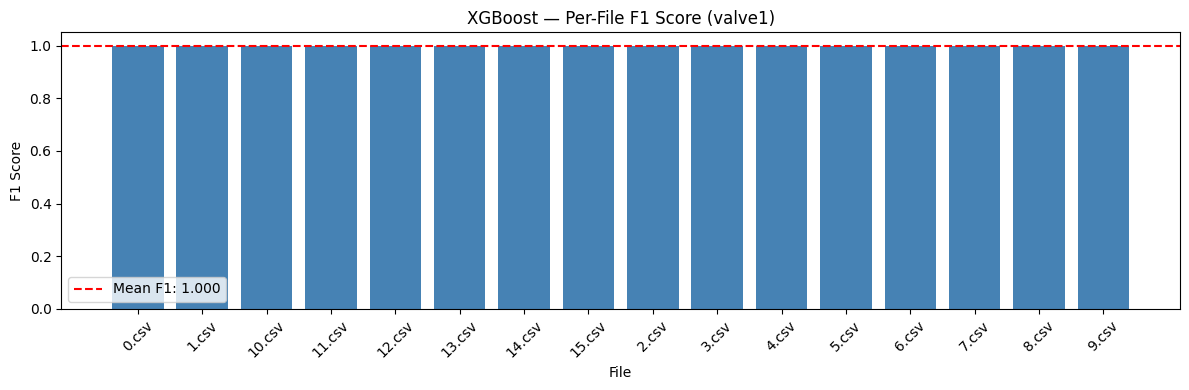

In [ ]:
from xgboost import XGBClassifier

# Train XGBoost on all data, evaluate per file
final_xgb = XGBClassifier(
    n_estimators=300, max_depth=6,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
final_xgb.fit(X_valve1, y_valve1)

per_file = []
for fname in sorted(valve1_feat['source_file'].unique()):
    mask = valve1_feat['source_file'] == fname
    preds = final_xgb.predict(X_valve1[mask])
    f1 = f1_score(y_valve1[mask], preds, zero_division=0)
    anom_rate = y_valve1[mask].mean()
    per_file.append({'File': fname, 'F1': round(f1, 4), 'Anomaly Rate': round(anom_rate, 3)})

per_file_df = pd.DataFrame(per_file).sort_values('F1', ascending=False)
print(per_file_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(per_file_df['File'], per_file_df['F1'], color='steelblue')
ax.axhline(per_file_df['F1'].mean(), color='red', linestyle='--', label=f'Mean F1: {per_file_df["F1"].mean():.3f}')
ax.set_xlabel('File')
ax.set_ylabel('F1 Score')
ax.set_title('XGBoost — Per-File F1 Score (valve1)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('per_file_f1.png', dpi=150, bbox_inches='tight')
plt.show()